# CE7076 Final Project — Molecular Graph Generation for Drug Discovery

**Research Question**: Can a graph-based generative model (JTVAE) produce more valid, unique, and drug-like novel molecules compared to a sequence-based baseline (CharRNN)?

**Dataset**: ZINC250k via MOSES benchmark (250,000 drug-like molecules)

**Outline**:
1. Environment setup & data download
2. Data exploration
3. CharRNN baseline — training & generation
4. JTVAE — vocabulary building, training & generation
5. Property optimization in latent space
6. Evaluation & comparison

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os, json, time, random
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from functools import partial
from tqdm import tqdm
from torch.utils.data import DataLoader
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, QED, AllChem
from IPython.display import display

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
os.makedirs('../results', exist_ok=True)


def save_grid_image(img, path):
    """Save an RDKit grid image to disk, handling both return types.

    Draw.MolsToGridImage returns a PIL Image in plain Python, but inside
    Jupyter (with RDKit's IPythonConsole hook active) it returns an
    IPython.core.display.Image that holds raw PNG bytes and has no .save().
    """
    if hasattr(img, 'save'):       # PIL Image
        img.save(path)
    elif hasattr(img, 'data'):     # IPython Image holding PNG bytes
        with open(path, 'wb') as f:
            f.write(img.data)
    else:
        raise TypeError(f'Cannot save image of type {type(img)}')


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.5.1+cu121


---
## Section 1 — Data Download & Exploration

In [2]:
from data.download import split_and_save, load as load_data

split_and_save()   # skips download if files already exist
train_smiles = load_data('train')
test_smiles  = load_data('test')
print(f'Train: {len(train_smiles):,}  |  Test: {len(test_smiles):,}')

[data] Found existing e:\dev\1142_CE7076\final_project\data\dataset_v1.csv, skipping download.
[data] Total rows: 1936962
[data]  train: 1584663, test: 176074
[data] Saved e:\dev\1142_CE7076\final_project\data\train.csv and e:\dev\1142_CE7076\final_project\data\test.csv
Train: 1,584,663  |  Test: 176,074


In [3]:
def compute_props(smiles_list, sample=5000):
    rows = []
    for smi in random.sample(smiles_list, min(sample, len(smiles_list))):
        mol = Chem.MolFromSmiles(smi)
        if mol is None: continue
        rows.append({
            'smiles': smi,
            'n_atoms': mol.GetNumAtoms(),
            'mw':   Descriptors.MolWt(mol),
            'logp': Descriptors.MolLogP(mol),
            'qed':  QED.qed(mol),
            'hbd':  Descriptors.NumHDonors(mol),
            'hba':  Descriptors.NumHAcceptors(mol),
            'rings': mol.GetRingInfo().NumRings(),
        })
    return pd.DataFrame(rows)

df_train = compute_props(train_smiles, sample=5000)
print(df_train.describe().round(2))

       n_atoms       mw     logp      qed      hbd      hba    rings
count  5000.00  5000.00  5000.00  5000.00  5000.00  5000.00  5000.00
mean     21.69   307.89     2.44     0.81     1.12     3.88     2.58
std       2.31    27.70     0.95     0.10     0.85     1.25     0.80
min      11.00   250.10    -2.66     0.32     0.00     1.00     0.00
25%      20.00   286.31     1.88     0.76     1.00     3.00     2.00
50%      22.00   311.33     2.56     0.82     1.00     4.00     3.00
75%      24.00   331.45     3.12     0.88     2.00     5.00     3.00
max      26.00   349.87     4.64     0.95     5.00     9.00     6.00


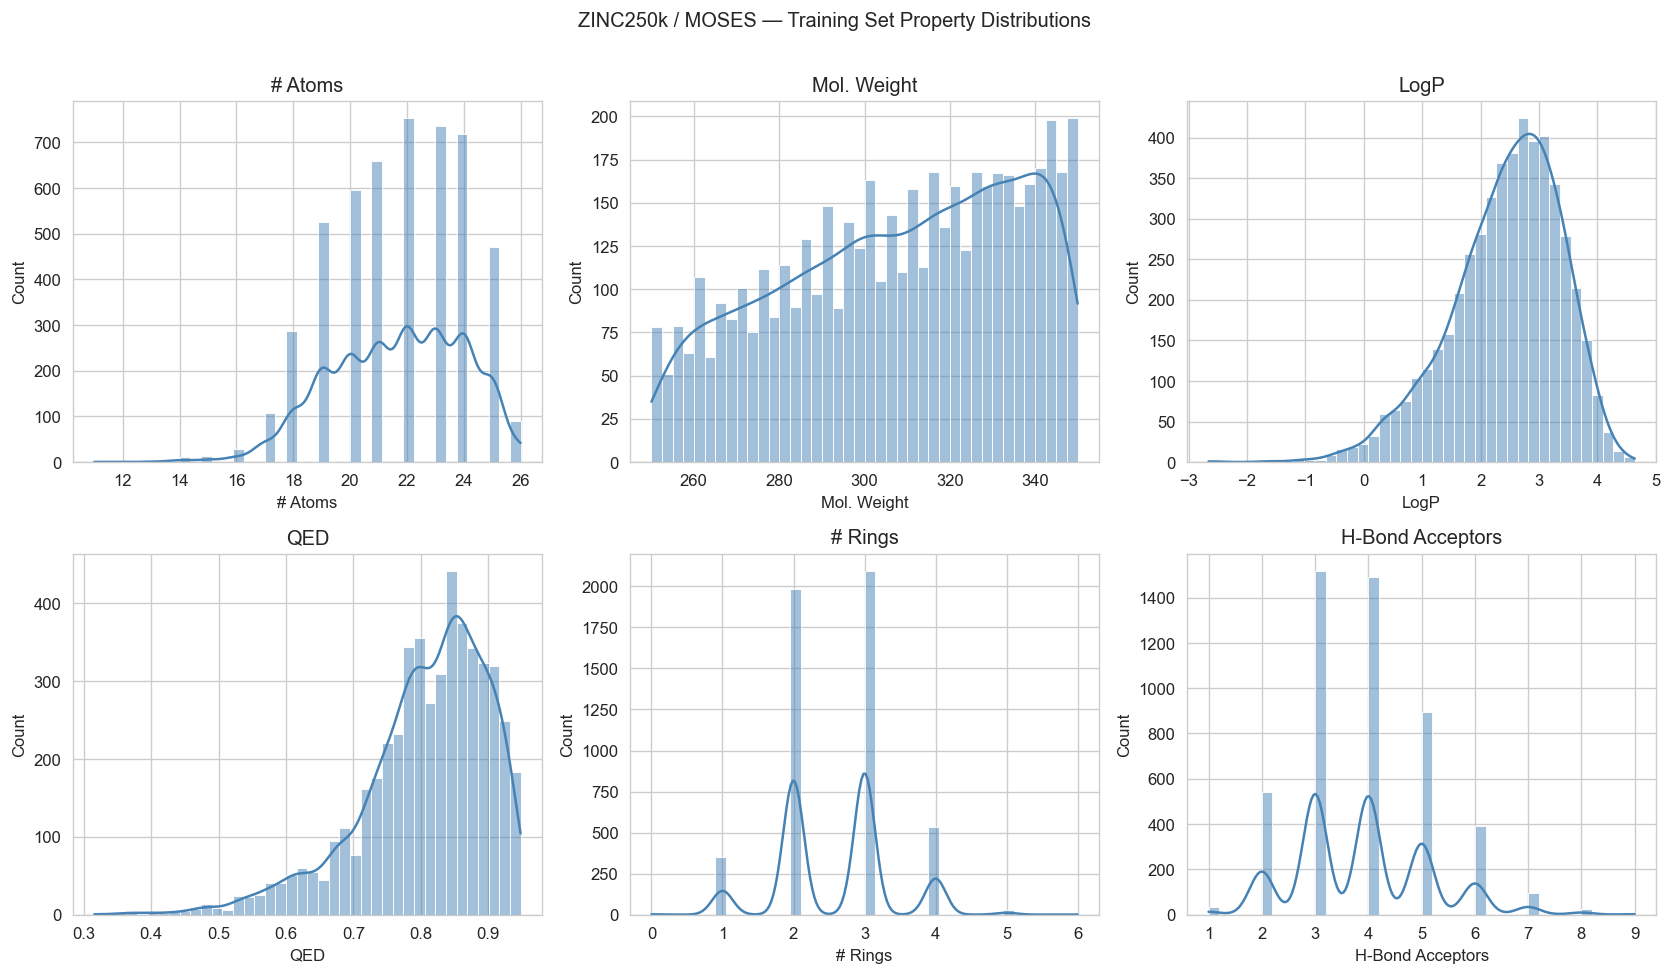

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
props = [('n_atoms','# Atoms'), ('mw','Mol. Weight'), ('logp','LogP'),
         ('qed','QED'), ('rings','# Rings'), ('hba','H-Bond Acceptors')]
for ax, (col, label) in zip(axes.flat, props):
    sns.histplot(df_train[col], ax=ax, bins=40, kde=True, color='steelblue')
    ax.set_xlabel(label); ax.set_title(label)
plt.suptitle('ZINC250k / MOSES — Training Set Property Distributions', y=1.01)
plt.tight_layout()
plt.savefig('../results/property_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

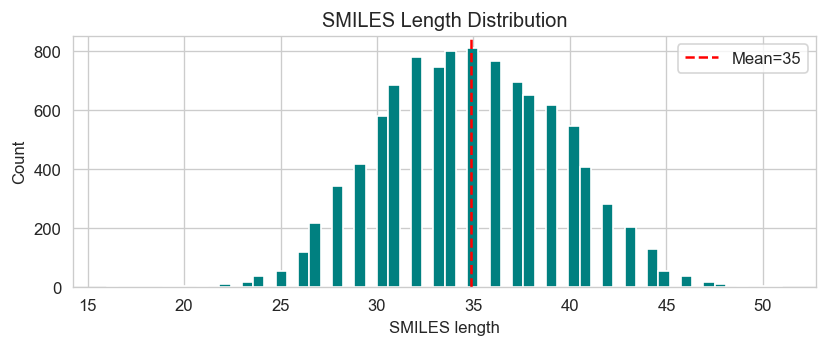

99th percentile length: 45


In [5]:
# SMILES length distribution
smi_len = [len(s) for s in train_smiles[:10000]]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(smi_len, bins=60, color='teal', edgecolor='white')
ax.axvline(np.mean(smi_len), color='red', linestyle='--',
           label=f'Mean={np.mean(smi_len):.0f}')
ax.set_xlabel('SMILES length'); ax.set_ylabel('Count')
ax.set_title('SMILES Length Distribution'); ax.legend()
plt.tight_layout()
plt.savefig('../results/smiles_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'99th percentile length: {np.percentile(smi_len, 99):.0f}')

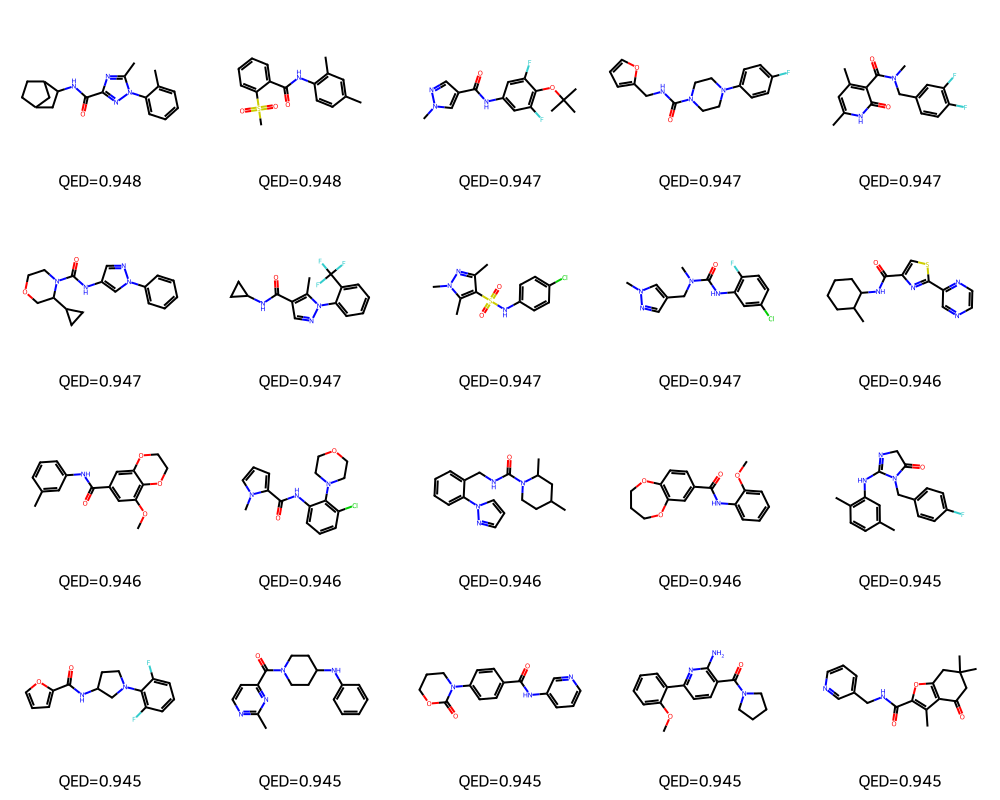

In [6]:
# Visualise top-20 molecules by QED
top_qed = df_train.nlargest(20, 'qed')
mols, legs = [], []
for _, row in top_qed.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        mols.append(mol); legs.append(f'QED={row["qed"]:.3f}')
img = Draw.MolsToGridImage(mols[:20], molsPerRow=5, subImgSize=(200,200), legends=legs[:20])
save_grid_image(img, '../results/top_qed_molecules.png')
display(img)

[20:12:48] Can't kekulize mol.  Unkekulized atoms: 1 2 11 12 13
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 1 2 3 22 23
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 9 10 11 16 21
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 13
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 10 12 20
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 7 8 21
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 4 5 15
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 7 8 20
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 14
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 4 5 9
[20:12:48] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5
[20:12:49] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 24
[20:12:49] Can't kekulize mol.  Unkekulized atoms: 15 16 17 18 19
[20:12:49] Can't kekulize mol.  Unkekulized atoms: 14 15 16
[20:12:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2
[20:12:49] Can't kekulize mol.  Unkekulize

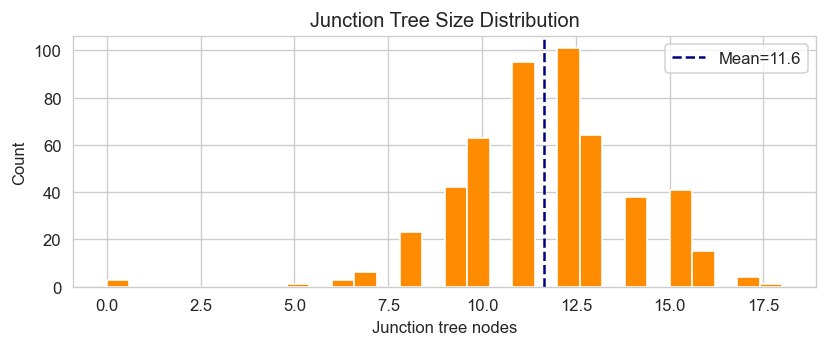

In [7]:
# Junction tree node count distribution
from models.jtvae.mol_tree import MolTree
node_counts = []
for smi in random.sample(train_smiles, 500):
    try:
        node_counts.append(len(MolTree(smi).nodes))
    except Exception: pass

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(node_counts, bins=30, color='darkorange', edgecolor='white')
ax.axvline(np.mean(node_counts), color='navy', linestyle='--',
           label=f'Mean={np.mean(node_counts):.1f}')
ax.set_xlabel('Junction tree nodes'); ax.set_ylabel('Count')
ax.set_title('Junction Tree Size Distribution'); ax.legend()
plt.tight_layout()
plt.savefig('../results/jt_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — CharRNN Baseline

In [8]:
from models.char_rnn.model import CharRNN, SMILESDataset, Vocabulary, collate_fn
from models.char_rnn.train import train_epoch, val_epoch

CR_SAVE = '../results/char_rnn'
os.makedirs(CR_SAVE, exist_ok=True)

MAX_LEN    = 120
BATCH_SIZE = 512
CR_EPOCHS  = 30

cr_train = train_smiles[:-5000]
cr_val   = train_smiles[-5000:]

vocab    = Vocabulary()
train_ds = SMILESDataset(cr_train, vocab, max_len=MAX_LEN)
val_ds   = SMILESDataset(cr_val,   vocab, max_len=MAX_LEN)
print(f'Vocab: {len(vocab)} | Train: {len(train_ds):,} | Val: {len(val_ds):,}')

_collate = partial(collate_fn, pad_idx=vocab.pad_idx)
cr_train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             collate_fn=_collate, pin_memory=True)
cr_val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                             collate_fn=_collate)

Vocab: 66 | Train: 1,579,663 | Val: 5,000


In [ ]:
CR_CKPT = f'{CR_SAVE}/char_rnn_best.pt'
CR_HIST = f'{CR_SAVE}/char_rnn_history.json'

if os.path.exists(CR_CKPT):
    # ── Load existing checkpoint ──────────────────────────────────────
    print(f'[CharRNN] Found checkpoint, loading from {CR_CKPT}')
    ckpt     = torch.load(CR_CKPT, map_location=DEVICE, weights_only=False)
    cr_model = CharRNN(vocab_size=len(vocab), embed_dim=128,
                       hidden_dim=512, num_layers=3, dropout=0.2).to(DEVICE)
    cr_model.load_state_dict(ckpt['model_state'])
    cr_model.eval()

    # History may be missing if training was interrupted (KeyboardInterrupt)
    cr_history = json.load(open(CR_HIST)) if os.path.exists(CR_HIST) else []
    # Best val loss: prefer value stored in checkpoint, fall back to history scan
    cr_best = ckpt.get('best_val_loss',
                        min((h['val_loss'] for h in cr_history), default=float('nan')))
    print(f'[CharRNN] Loaded epoch {ckpt.get("epoch","?")}. '
          f'Best val loss: {cr_best:.4f}  '
          f'History epochs: {len(cr_history)}')

else:
    # ── Train from scratch ────────────────────────────────────────────
    cr_model = CharRNN(vocab_size=len(vocab), embed_dim=128,
                       hidden_dim=512, num_layers=3, dropout=0.2).to(DEVICE)
    print(f'[CharRNN] parameters: {sum(p.numel() for p in cr_model.parameters()):,}')

    cr_opt  = torch.optim.Adam(cr_model.parameters(), lr=1e-3)
    cr_sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(cr_opt, patience=3, factor=0.5)
    cr_crit = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

    cr_history  = []
    cr_best     = float('inf')
    ES_PATIENCE = 5
    es_counter  = 0

    for epoch in range(1, CR_EPOCHS + 1):
        t0 = time.time()
        tr = train_epoch(cr_model, cr_train_loader, cr_opt, cr_crit, DEVICE, vocab)
        va = val_epoch(cr_model, cr_val_loader, cr_crit, DEVICE, vocab)
        cr_sch.step(va)
        cr_history.append({'epoch': epoch, 'train_loss': tr, 'val_loss': va})
        print(f'[CharRNN] Epoch {epoch:3d} | train={tr:.4f} | val={va:.4f} | {time.time()-t0:.1f}s', end='')

        if va < cr_best:
            cr_best = va; es_counter = 0
            torch.save({'model_state': cr_model.state_dict(), 'vocab': vocab,
                        'epoch': epoch, 'best_val_loss': cr_best}, CR_CKPT)
            print(' *')
        else:
            es_counter += 1
            print(f'  (no improvement {es_counter}/{ES_PATIENCE})')
            if es_counter >= ES_PATIENCE:
                print(f'[CharRNN] Early stop at epoch {epoch}.'); break

    json.dump(cr_history, open(CR_HIST, 'w'), indent=2)
    print(f'CharRNN done. Best val loss: {cr_best:.4f}')

In [10]:
CR_GEN_CSV = f'{CR_SAVE}/char_rnn_generated.csv'

if os.path.exists(CR_GEN_CSV):
    print(f'[CharRNN] Found generated molecules, loading from {CR_GEN_CSV}')
    cr_generated = pd.read_csv(CR_GEN_CSV)['SMILES'].tolist()
    print(f'[CharRNN] Loaded {len(cr_generated):,} SMILES.')
else:
    ckpt = torch.load(CR_CKPT, map_location=DEVICE, weights_only=False)
    cr_model.load_state_dict(ckpt['model_state'])
    cr_model.eval()
    print('CharRNN: generating 10,000 molecules...')
    cr_generated = []
    for _ in tqdm(range(20)):
        cr_generated.extend(cr_model.generate(vocab, n=500, max_len=MAX_LEN,
                                               temperature=1.0, device=DEVICE))
    pd.DataFrame({'SMILES': cr_generated}).to_csv(CR_GEN_CSV, index=False)
    print(f'Generated {len(cr_generated):,} SMILES.')

[CharRNN] Found generated molecules, loading from ../results/char_rnn/char_rnn_generated.csv
[CharRNN] Loaded 10,000 SMILES.


---
## Section 3 — JTVAE

In [11]:
from models.jtvae.mol_tree import Vocab, build_vocab
from models.jtvae.jtnn_vae import JTVAE
from models.jtvae.train import JTVAEDataset, jtvae_collate, train_one_epoch, anneal_beta

JT_SAVE    = '../results/jtvae'
VOCAB_PATH = '../data/vocab.txt'
os.makedirs(JT_SAVE, exist_ok=True)

# Build / load vocabulary
if os.path.exists(VOCAB_PATH):
    with open(VOCAB_PATH) as f:
        vocab_list = [l.strip() for l in f if l.strip()]
    jt_vocab = Vocab(vocab_list)
    print(f'Loaded vocab: {len(jt_vocab)} entries')
else:
    print('Building vocab from 50k SMILES ...')
    jt_vocab = build_vocab(train_smiles[:50000])
    with open(VOCAB_PATH, 'w') as f:
        [f.write(s + '\n') for s in jt_vocab.vocab]
    print(f'Vocab size: {len(jt_vocab)}, saved to {VOCAB_PATH}')

Loaded vocab: 287 entries


In [ ]:
# Use 80k samples for ~2-3hr training; increase SUBSET for better results
SUBSET     = 80000
JT_BATCH   = 32
JT_EPOCHS  = 30

jt_train_ds = JTVAEDataset(train_smiles[:SUBSET], jt_vocab, n_workers=0)
jt_val_ds   = JTVAEDataset(train_smiles[-2000:],  jt_vocab, n_workers=0)
print(f'JT Train: {len(jt_train_ds):,}  |  JT Val: {len(jt_val_ds):,}')

jt_loader     = DataLoader(jt_train_ds, batch_size=JT_BATCH, shuffle=True,
                           collate_fn=jtvae_collate, num_workers=0)
jt_val_loader = DataLoader(jt_val_ds,   batch_size=JT_BATCH, shuffle=False,
                           collate_fn=jtvae_collate, num_workers=0)

[JTVAEDataset] Parsing 80,000 SMILES ...


[20:12:56] Can't kekulize mol.  Unkekulized atoms: 11 16 25
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 4 5 12
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 12
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 3 15 19
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 6 19 24
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 2 3 6 7 18
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 5 6 7 14 19
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 12 19 20 21 22
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 16
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 4 6 12
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 3 4 5 16 17
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 2 3 4 15 16
[20:12:56] Can't kekulize mol.  Unkekulized atoms: 6 13 22
[20:12:56] C

In [ ]:
JT_CKPT = f'{JT_SAVE}/jtvae_best.pt'
JT_HIST = f'{JT_SAVE}/jtvae_history.json'

if os.path.exists(JT_CKPT):
    # ── Load existing checkpoint ──────────────────────────────────────
    print(f'[JTVAE] Found checkpoint, loading from {JT_CKPT}')
    ckpt     = torch.load(JT_CKPT, map_location=DEVICE, weights_only=False)
    jt_model = JTVAE(vocab=jt_vocab, hidden_dim=300, latent_dim=56,
                     depth_t=1, depth_g=3).to(DEVICE)
    jt_model.load_state_dict(ckpt['model_state'])
    jt_model.eval()
    jt_history = json.load(open(JT_HIST)) if os.path.exists(JT_HIST) else []
    jt_best    = min(h['loss'] for h in jt_history) if jt_history else float('nan')
    print(f'[JTVAE] Loaded epoch {ckpt["epoch"]}. Best loss: {jt_best:.4f}')

else:
    # ── Train from scratch ────────────────────────────────────────────
    jt_model = JTVAE(vocab=jt_vocab, hidden_dim=300, latent_dim=56,
                     depth_t=1, depth_g=3).to(DEVICE)
    print(f'JTVAE parameters: {sum(p.numel() for p in jt_model.parameters()):,}')

    jt_opt = torch.optim.Adam(jt_model.parameters(), lr=1e-3)
    jt_sch = torch.optim.lr_scheduler.StepLR(jt_opt, step_size=10, gamma=0.9)

    jt_history  = []
    jt_best     = float('inf')
    best_rec    = float('inf')
    ES_PATIENCE = 5
    es_counter  = 0

    for epoch in range(1, JT_EPOCHS + 1):
        beta  = anneal_beta(epoch, JT_EPOCHS, beta_max=1.0, warmup=5)
        t0    = time.time()
        stats = train_one_epoch(jt_model, jt_loader, jt_opt, DEVICE, beta)
        jt_sch.step()
        elapsed = time.time() - t0
        print(f'[JTVAE] Epoch {epoch:3d} | beta={beta:.2f} | '
              f'loss={stats["loss"]:.4f} | rec={stats["rec_loss"]:.4f} | '
              f'kl={stats["kl_loss"]:.4f} | {elapsed:.1f}s', end='')
        jt_history.append({'epoch': epoch, 'beta': beta, 'time': elapsed, **stats})

        # Save best checkpoint whenever total loss improves
        if stats['loss'] < jt_best:
            jt_best = stats['loss']
            torch.save({'epoch': epoch, 'model_state': jt_model.state_dict(),
                        'vocab': jt_vocab, 'args': {'hidden_dim': 300, 'latent_dim': 56},
                        'best_loss': jt_best},
                       JT_CKPT)

        # Save history every epoch (so it survives a KeyboardInterrupt)
        json.dump(jt_history, open(JT_HIST, 'w'), indent=2)

        # Early stopping on reconstruction loss (after KL warmup)
        if epoch > 5:
            if stats['rec_loss'] < best_rec:
                best_rec = stats['rec_loss']; es_counter = 0; print(' *')
            else:
                es_counter += 1
                print(f'  (no improve {es_counter}/{ES_PATIENCE})')
                if es_counter >= ES_PATIENCE:
                    print(f'[JTVAE] Early stop at epoch {epoch}.'); break
        else:
            print(f'  (warmup)')  # first 5 epochs: no early stopping

        # Periodic checkpoint every 5 epochs for resumability
        if epoch % 5 == 0:
            torch.save({'epoch': epoch, 'model_state': jt_model.state_dict(),
                        'vocab': jt_vocab}, f'{JT_SAVE}/jtvae_epoch{epoch}.pt')

    print(f'JTVAE done. Best loss: {jt_best:.4f}')

In [ ]:
JT_GEN_CSV = f'{JT_SAVE}/jtvae_generated.csv'

if os.path.exists(JT_GEN_CSV):
    print(f'[JTVAE] Found generated molecules, loading from {JT_GEN_CSV}')
    jt_generated = pd.read_csv(JT_GEN_CSV)['SMILES'].tolist()
    print(f'[JTVAE] Loaded {len(jt_generated):,} SMILES.')
else:
    jt_model.eval()
    print('JTVAE: generating 10,000 molecules...')
    jt_generated = []
    with torch.no_grad():
        for _ in tqdm(range(50)):
            jt_generated.extend(jt_model.generate(n=200, temperature=1.0))
    jt_generated = [s for s in jt_generated if s]
    pd.DataFrame({'SMILES': jt_generated}).to_csv(JT_GEN_CSV, index=False)
    print(f'Generated {len(jt_generated):,} non-empty SMILES.')

---
## Section 4 — Property Optimization (JTVAE Latent Space)

In [ ]:
from optimization.property_optimize import gradient_ascent, score_smiles

# Encode 200 test molecules as seed
seed_trees = []
seed_smi   = []
for smi in random.sample(test_smiles, 300):
    try:
        t = MolTree(smi)
        if all(n.smiles in jt_vocab for n in t.nodes) and t.nodes:
            for n in t.nodes: n.wid = jt_vocab[n.smiles]
            seed_trees.append(t)
            seed_smi.append(smi)
            if len(seed_trees) >= 200: break
    except Exception: pass

print(f'Seed molecules: {len(seed_trees)}')

with torch.no_grad():
    z_seed, _, _ = jt_model.encode(seed_trees)
print(f'Latent z shape: {z_seed.shape}')

[19:16:52] Can't kekulize mol.  Unkekulized atoms: 1 2 20
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 18
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 15 16 17 18 19
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 1 2 23
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 0 1 3 4 5
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 2 3 21
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 17
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 12 16 21
[19:16:52] Can't kekulize mol.  Unkekulized atoms: 0 1 3 4 5


Seed molecules: 200


RecursionError: maximum recursion depth exceeded

In [ ]:
# Run gradient-based optimization (faster than BO for demonstration)
opt_records = gradient_ascent(jt_model, z_seed, n_steps=100, lr=0.02, temperature=1.0)

opt_df = pd.DataFrame(opt_records)
opt_df.to_csv('../results/optimized_molecules.csv', index=False)

valid_opt = opt_df[opt_df['qed'] > 0]
print(f'Optimized molecules with QED > 0: {len(valid_opt):,}')
print(f'Best QED:  {valid_opt["qed"].max():.4f}')
print(f'Mean QED:  {valid_opt["qed"].mean():.4f}')
print(f'Seed mean: {np.mean(score_smiles(seed_smi)):.4f}')

---
## Section 5 — Evaluation & Comparison

In [ ]:
from rdkit import RDLogger
from evaluation.metrics import get_all_metrics, print_metrics, get_valid

# Silence RDKit's per-molecule parse/kekulize messages for the rest of the
# notebook. Generated SMILES are often invalid by design — that is exactly
# what the validity metric measures — so we suppress the console spam and
# report a summary instead. We intentionally do NOT re-enable logging, so the
# downstream Section-5 cells (property plots, molecule grids) stay quiet too.
RDLogger.DisableLog('rdApp.*')


def invalid_summary(name, smiles_list):
    """Print how many generated SMILES are valid vs invalid."""
    total   = len(smiles_list)
    valid   = len(get_valid(smiles_list))
    invalid = total - valid
    print(f'[{name}] total={total:,}  valid={valid:,}  '
          f'invalid={invalid:,} ({100*invalid/max(total,1):.1f}%)')


print('Computing CharRNN metrics ...')
invalid_summary('CharRNN', cr_generated)
cr_metrics = get_all_metrics(cr_generated, train=train_smiles, test=test_smiles)
with open(f'{CR_SAVE}/char_rnn_metrics.json', 'w') as f: json.dump(cr_metrics, f, indent=2)

print('\nComputing JTVAE metrics ...')
invalid_summary('JTVAE', jt_generated)
jt_metrics = get_all_metrics(jt_generated, train=train_smiles, test=test_smiles)
with open(f'{JT_SAVE}/jtvae_metrics.json', 'w') as f: json.dump(jt_metrics, f, indent=2)

print('\n--- CharRNN ---')
print_metrics(cr_metrics)
print('--- JTVAE ---')
print_metrics(jt_metrics)

In [ ]:
# Side-by-side comparison table
KEY_METRICS = ['validity','uniqueness','novelty','internal_diversity',
               'snn','fcd','qed_mean','sa_mean','logp_mean']
rows = []
for k in KEY_METRICS:
    cv, jv = cr_metrics.get(k, float('nan')), jt_metrics.get(k, float('nan'))
    better = '↑ JTVAE' if (isinstance(jv, float) and isinstance(cv, float)
                           and k != 'fcd' and jv > cv) else (
              '↑ JTVAE' if k == 'fcd' and isinstance(jv, float) and
                           isinstance(cv, float) and jv < cv else '')
    rows.append({'Metric': k,
                 'CharRNN': f'{cv:.4f}' if isinstance(cv,float) else str(cv),
                 'JTVAE':   f'{jv:.4f}' if isinstance(jv,float) else str(jv),
                 'Better':  better})
cmp_df = pd.DataFrame(rows).set_index('Metric')
display(cmp_df)
cmp_df.to_csv('../results/model_comparison.csv')

In [ ]:
# Bar chart
bar_keys = ['validity','uniqueness','novelty','internal_diversity','qed_mean']
cr_vals = [cr_metrics.get(k, 0.0) for k in bar_keys]
jt_vals = [jt_metrics.get(k, 0.0) for k in bar_keys]

x = np.arange(len(bar_keys))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, cr_vals, w, label='CharRNN', color='steelblue')
ax.bar(x + w/2, jt_vals, w, label='JTVAE',   color='darkorange')
ax.set_xticks(x); ax.set_xticklabels([k.replace('_','\n') for k in bar_keys])
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('CharRNN vs. JTVAE — MOSES Metrics'); ax.legend()
plt.tight_layout()
plt.savefig('../results/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot([h['epoch'] for h in cr_history], [h['train_loss'] for h in cr_history], label='Train')
axes[0].plot([h['epoch'] for h in cr_history], [h['val_loss']   for h in cr_history], '--', label='Val')
axes[0].set_title('CharRNN Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot([h['epoch'] for h in jt_history], [h['loss']     for h in jt_history], label='Total')
axes[1].plot([h['epoch'] for h in jt_history], [h['rec_loss'] for h in jt_history], '--', label='Recon')
axes[1].plot([h['epoch'] for h in jt_history], [h['kl_loss']  for h in jt_history], ':',  label='KL')
axes[1].set_title('JTVAE Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Property distribution comparison
from rdkit import RDLogger; RDLogger.DisableLog('rdApp.*')   # quiet invalid-SMILES warnings

def mol_props(smiles_list, n=2000):
    rows = []
    for smi in smiles_list[:n]:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            rows.append({'qed': QED.qed(mol), 'logp': Descriptors.MolLogP(mol),
                         'mw': Descriptors.MolWt(mol)})
    return pd.DataFrame(rows)

sets = {'Train': random.sample(train_smiles, 2000),
        'CharRNN': cr_generated, 'JTVAE': jt_generated}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ['#2196F3', '#FF5722', '#4CAF50']
for prop, ax in zip(['qed', 'logp', 'mw'], axes):
    for (name, smi_list), color in zip(sets.items(), palette):
        df = mol_props(smi_list)
        if prop in df.columns:
            sns.kdeplot(df[prop], ax=ax, label=name, color=color, fill=True, alpha=0.25)
    ax.set_xlabel({'qed':'QED','logp':'LogP','mw':'Mol. Weight'}[prop])
    ax.set_title(f'{prop.upper()} Distribution'); ax.legend(fontsize=8)

plt.suptitle('Property Distributions: Training vs. Generated', y=1.01)
plt.tight_layout()
plt.savefig('../results/property_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# t-SNE of JTVAE latent space
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Encode test molecules
enc_trees, enc_smi, enc_qeds = [], [], []
for smi in random.sample(test_smiles, 600):
    try:
        t = MolTree(smi)
        if all(n.smiles in jt_vocab for n in t.nodes) and t.nodes:
            for n in t.nodes: n.wid = jt_vocab[n.smiles]
            mol = Chem.MolFromSmiles(smi)
            if mol:
                enc_trees.append(t); enc_smi.append(smi)
                enc_qeds.append(QED.qed(mol))
            if len(enc_trees) >= 400: break
    except Exception: pass

with torch.no_grad():
    z_enc, _, _ = jt_model.encode(enc_trees)
z_np = z_enc.cpu().numpy()
qed_np = np.array(enc_qeds)

z_pca = PCA(n_components=30).fit_transform(z_np)
z_2d  = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(z_pca)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(z_2d[:,0], z_2d[:,1], c=qed_np, cmap='viridis', s=15, alpha=0.7)
plt.colorbar(sc, ax=ax, label='QED')
ax.set_title('JTVAE Latent Space (t-SNE) — coloured by QED')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
plt.tight_layout()
plt.savefig('../results/latent_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Top generated molecules by QED (JTVAE)
from rdkit import RDLogger; RDLogger.DisableLog('rdApp.*')   # quiet invalid-SMILES warnings

jt_scored = [(s, QED.qed(Chem.MolFromSmiles(s)))
             for s in jt_generated if Chem.MolFromSmiles(s)]
jt_scored.sort(key=lambda x: -x[1])

mols = [Chem.MolFromSmiles(s) for s,_ in jt_scored[:20]]
legs = [f'QED={q:.3f}' for _,q in jt_scored[:20]]
img  = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200,200), legends=legs)
save_grid_image(img, '../results/jtvae_top_molecules.png')
display(img)

In [ ]:
# Optimization progress plot
if os.path.exists('../results/optimized_molecules.csv'):
    opt_df = pd.read_csv('../results/optimized_molecules.csv')
    best_per_step = opt_df[opt_df['qed'] > 0].groupby('step')['qed'].max()
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(best_per_step.index, best_per_step.values, marker='o', markersize=4)
    ax.set_xlabel('Optimization Step'); ax.set_ylabel('Best QED')
    ax.set_title('Property Optimization Progress (Gradient Ascent in Latent Space)')
    plt.tight_layout()
    plt.savefig('../results/optimization_progress.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Best optimized QED: {opt_df["qed"].max():.4f}')

In [ ]:
# Final summary
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'{"Metric":<25} {"CharRNN":>12} {"JTVAE":>12}')
print('-' * 60)
for k in ['validity','uniqueness','novelty','internal_diversity',
          'qed_mean','fcd']:
    cv = cr_metrics.get(k, float('nan'))
    jv = jt_metrics.get(k, float('nan'))
    print(f'{k:<25} {cv:>12.4f} {jv:>12.4f}')
print('=' * 60)